# Compare savegames (locations over time)

Loads format-2 `.pkl` snapshots and merges them with `LocationData` (same pipeline as other savegame notebooks).

**Building counts:** `BUILDING_INCLUDE_ALL = True` loads the **union of every building type** across your snapshots (each location gets `bldg_<type>` for all of them; zeros where absent). Set `BUILDING_INCLUDE_ALL = False` and use `BUILDING_SLUGS` to restrict types. `build_save_comparison_df` accepts **multiple metrics**: after loading, use every `bldg_*` column in one table (see the cell below the main `comparison_df`) or set `metric = "bldg_cookery"` for the line charts only.

In [93]:
"""Load all .pkl files from save_game_temp, ordered by timestamp (YYYYMMDD_HHMMSS)."""
import pandas as pd

from analysis.savegame import (
    build_save_comparison_df,
    get_religion_data,
    merge_saves_with_location_data,
    resolve_pkl_dir,
)

# None = auto (newest playthrough), or set path directly
# PKL_PATH = "C:/Development/ProsperPerishCalcs/analysis/savegame/notebooks/save_game_temp/f3d0f1ca_a56c_42ea_acc9_4c4a7c4a7a01"
PKL_PATH = None
first_savegame = 0   # None = from start
last_savegame = 100  # None = to end

pkl_dir = resolve_pkl_dir(PKL_PATH)
pkl_files = sorted(pkl_dir.glob("*.pkl"), key=lambda p: p.stem)[first_savegame:last_savegame]
saves = {p.stem: pd.read_pickle(p) for p in pkl_files}

# Optional: per-location building totals (columns bldg_<type>); merge with full LocationData
BUILDING_INCLUDE_ALL = False  # all building types (union across snapshots); set False to use BUILDING_SLUGS only
BUILDING_SLUGS = ("cookery", "farming_village", "fishing_village", "forest_village", "fruit_orchard", "sheep_farms", "lumber_mill", "fiber_crops_farm", "horse_breeders")  # ignored when BUILDING_INCLUDE_ALL is True; () skips buildings when False
BUILDING_COUNT_MODE = "levels"  # "levels" (sum level) or "instances" (rows per building type)

saves = merge_saves_with_location_data(
    saves,
    building_slugs=None if BUILDING_INCLUDE_ALL else (BUILDING_SLUGS if BUILDING_SLUGS else None),
    include_all_building_types=BUILDING_INCLUDE_ALL,
    building_count_mode=BUILDING_COUNT_MODE,
)
print(f"Loaded {len(saves)} snapshots from {pkl_dir}: {list(saves.keys())[:5]}{'...' if len(saves) > 5 else ''}")

Loaded 100 snapshots from C:\Development\ProsperPerishCalcs\analysis\savegame\notebooks\save_game_temp\5cc58dda_a771_4ccd_b17d_1f88b360b2a9: ['20260325_160944', '20260325_161108', '20260325_161229', '20260325_161356', '20260325_161522']...


In [94]:
"""Config: pick any column for groupby. Change comparison, metric, n, order freely."""
if not saves:
    raise FileNotFoundError("No .pkl files in save_game_temp. Run the processor first.")
sample = next(iter(saves.values()))
available_group_cols = [c for c in sample.columns if c not in ("slug", "location_id", "name")]
print("Available group-by columns:", available_group_cols)

comparison = "macro_region_pkl" # pick from available_group_cols above
metric = "total_population"  # or "development", or e.g. "bldg_cookery" when BUILDING_SLUGS includes cookery
n = 10
order = "top"  # or "bottom"
aggregation_method = "sum"  # or "mean", "median", "min", "max"

Available group-by columns: ['province_pkl', 'area_pkl', 'region_pkl', 'macro_region_pkl', 'super_region_pkl', 'owner_country_id', 'country_tag', 'controller_country_id', 'controller_tag', 'rank_pkl', 'development_pkl', 'total_population', 'tax', 'possible_tax', 'nobles', 'nobles_u', 'clergy', 'clergy_u', 'burghers', 'burghers_u', 'soldiers', 'soldiers_u', 'laborers', 'laborers_u', 'peasants', 'peasants_u', 'tribesmen', 'tribesmen_u', 'slaves', 'slaves_u', 'name_pkl', 'owner', 'controller', 'previous_owner', 'market', 'second_best_market', 'market_access', 'market_attraction', 'second_best_market_access', 'cores', 'religion_pkl', 'culture_pkl', 'secondary_culture', 'cultural_unity', 'language', 'dialect', 'last_owner_change', 'last_controller_change', 'raw_material_pkl', 'max_raw_material_workers', 'prosperity', 'control', 'road_to_capital', 'proximity', 'local_proximity_propagation', 'value_flow', 'winter', 'population_pkl', 'owner_name', 'market_name', 'province_slug', 'nobles_tax', 

In [95]:
comparison_df = build_save_comparison_df(
    saves, comparison, metric_cols=(metric,), aggregation_method=aggregation_method
)
if comparison_df.empty:
    raise ValueError(f"Comparison failed. Check that '{comparison}' exists. Available: {available_group_cols}")

# Resolve religion IDs to display names when grouping by religion
if comparison == "religion_pkl":
    religion_data = get_religion_data()
    comparison_df[comparison] = comparison_df[comparison].map(religion_data.resolve)

# Top N by aggregate (sum/mean/median across snapshots)
metric_cols = [c for c in comparison_df.columns if c.startswith(f"{metric}_")]
agg_fn = getattr(comparison_df[metric_cols], aggregation_method)
comparison_df["_agg"] = pd.to_numeric(agg_fn(axis=1), errors="coerce")
sel_fn = comparison_df.nlargest if order == "top" else comparison_df.nsmallest
top_df = sel_fn(n, "_agg").drop(columns=["_agg"])
comparison_df = comparison_df.drop(columns=["_agg"])
# top_df

C:\Users\Anwender\AppData\Local\Temp\ipykernel_10164\1752144732.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  comparison_df["_agg"] = pd.to_numeric(agg_fn(axis=1), errors="coerce")


In [96]:
# All building metrics at once: one row per comparison group, columns = bldg_<type>_<snapshot>
sample = next(iter(saves.values()))
bldg_cols = [c for c in sample.columns if c.startswith("bldg_")]
if bldg_cols:
    comparison_bldg_wide = build_save_comparison_df(
        saves, comparison, metric_cols=tuple(bldg_cols), aggregation_method=aggregation_method
    )
    display(comparison_bldg_wide)
    print(f"bldg_* columns: {len(bldg_cols)}")
else:
    print("No bldg_* columns — set BUILDING_INCLUDE_ALL or BUILDING_SLUGS in the load cell.")

C:\Development\ProsperPerishCalcs\analysis\savegame\loader.py:864: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged = merged.reset_index()


,macro_region_pkl,bldg_cookery_20260325_160944,bldg_farming_village_20260325_160944,bldg_fishing_village_20260325_160944,bldg_forest_village_20260325_160944,bldg_fruit_orchard_20260325_160944,bldg_sheep_farms_20260325_160944,bldg_lumber_mill_20260325_160944,bldg_fiber_crops_farm_20260325_160944,bldg_horse_breeders_20260325_160944,...,bldg_horse_breeders_20260325_182335,bldg_cookery_20260325_182520,bldg_farming_village_20260325_182520,bldg_fishing_village_20260325_182520,bldg_forest_village_20260325_182520,bldg_fruit_orchard_20260325_182520,bldg_sheep_farms_20260325_182520,bldg_lumber_mill_20260325_182520,bldg_fiber_crops_farm_20260325_182520,bldg_horse_breeders_20260325_182520
0,antarctic_ocean_sub_continent,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,australasia,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,4.0,0.0,0.0,0.0,3.0,0.0,0.0
2,central_africa,7.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,110.0,47.0,337.0,65.0,124.0,81.0,127.0,23.0,0.0
3,central_asia,24.0,1.0,15.0,2.0,1.0,0.0,1.0,0.0,0.0,...,45.0,87.0,173.0,84.0,40.0,39.0,20.0,11.0,13.0,50.0
4,east_africa,66.0,8.0,20.0,0.0,6.0,21.0,2.0,3.0,0.0,...,11.0,174.0,189.0,479.0,15.0,133.0,22.0,83.0,56.0,15.0
5,east_asia,504.0,138.0,42.0,14.0,7.0,12.0,33.0,2.0,11.0,...,1009.0,1648.0,2673.0,1439.0,423.0,1041.0,291.0,724.0,448.0,1013.0
6,eastern_europe,195.0,3.0,109.0,0.0,80.0,41.0,0.0,0.0,0.0,...,403.0,919.0,1539.0,1458.0,226.0,685.0,163.0,358.0,108.0,419.0
7,indian_ocean_sub_continent,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,middle_east,171.0,17.0,65.0,0.0,21.0,9.0,1.0,3.0,0.0,...,240.0,391.0,621.0,497.0,58.0,138.0,25.0,78.0,53.0,244.0
9,north_africa,41.0,18.0,14.0,0.0,4.0,0.0,8.0,0.0,0.0,...,108.0,178.0,220.0,215.0,22.0,61.0,6.0,76.0,24.0,115.0


bldg_* columns: 9


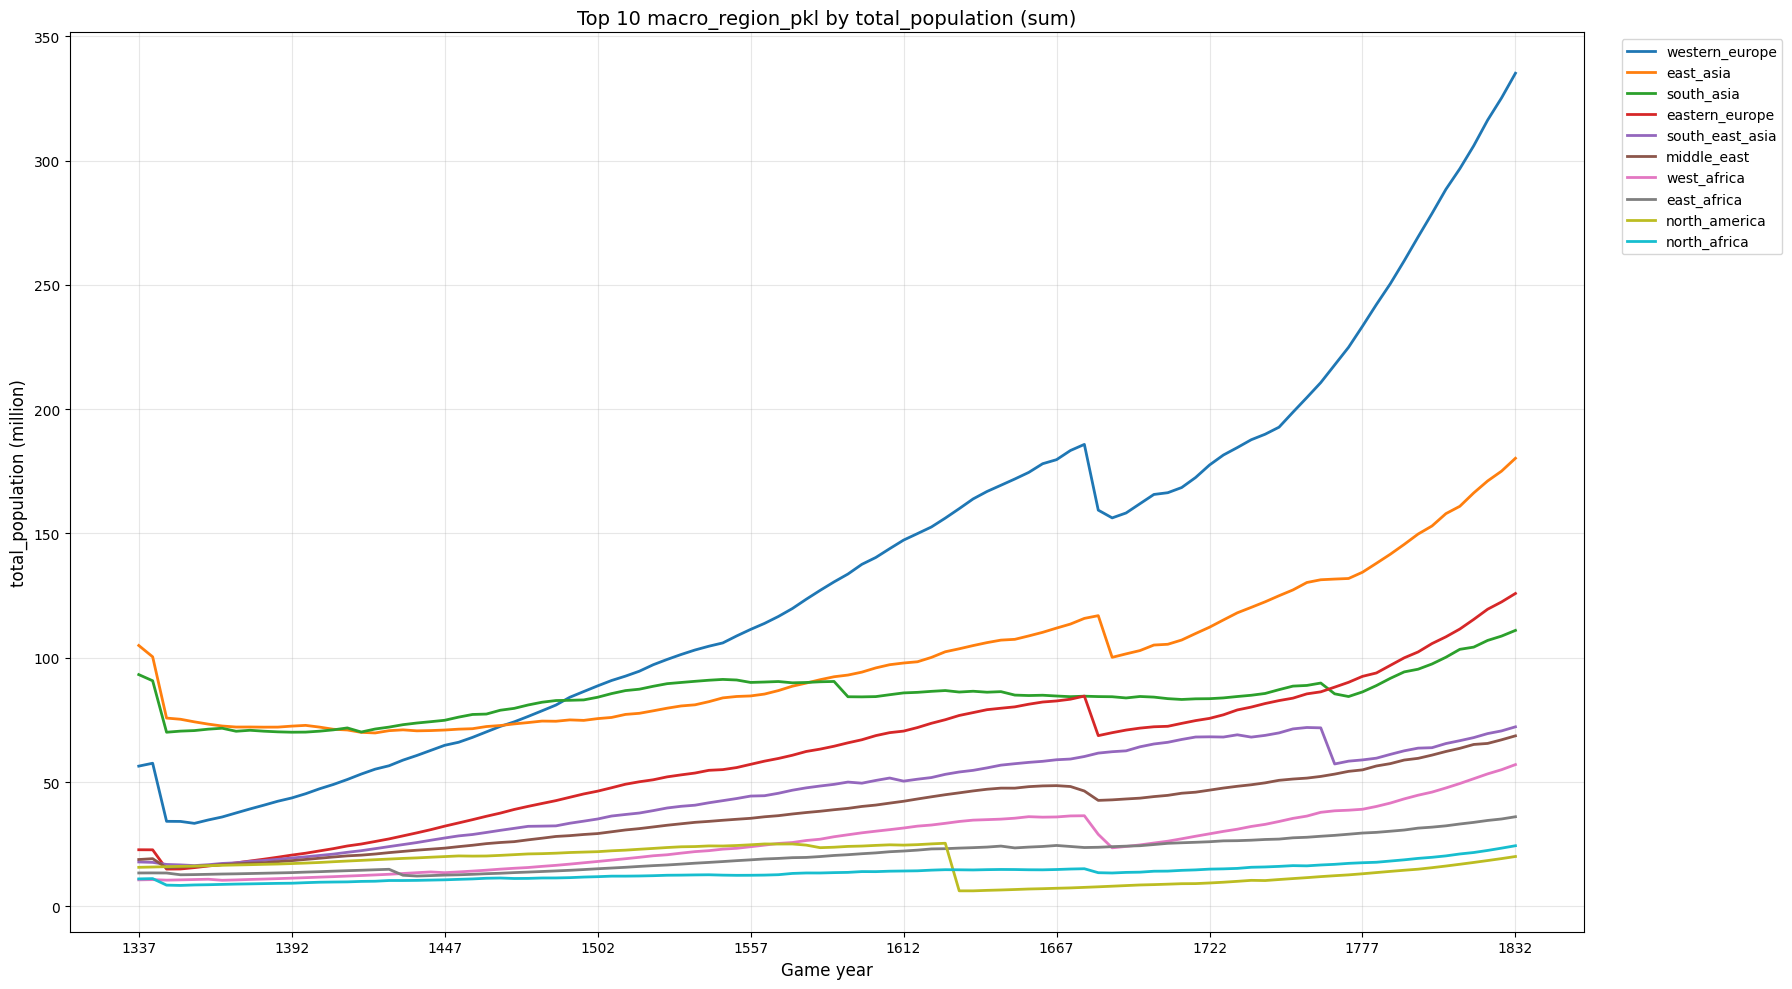

In [97]:
import matplotlib.pyplot as plt

# Plot: x = snapshots (ordered), y = metric, one line per top-N group
# Each pkl = 5 game years; ~10 x-ticks labeled every 50 years
years_per_snapshot = 5
start_year = 1337  # EU5 start
n_ticks = 10

plot_cols = [c for c in top_df.columns if c.startswith(f"{metric}_")]
plot_data = top_df.set_index(comparison)[plot_cols].T

# Scale to millions for population only; building metrics (bldg_*) and dev use raw units
scale = 1e6 if metric in ("total_population", "population") else 1
plot_data = plot_data / scale
ylabel = f"{metric} (million)" if scale > 1 else metric

fig, ax = plt.subplots(figsize=(18, 10))
plot_data.plot(ax=ax, linewidth=2, markersize=4)
order_label = "Top" if order == "top" else "Bottom"
ax.set_title(f"{order_label} {n} {comparison} by {metric} ({aggregation_method})", fontsize=14)
ax.set_xlabel("Game year", fontsize=12)
ax.set_ylabel(ylabel, fontsize=12)
ax.tick_params(axis="both", labelsize=10)
ax.grid(True, axis="both", alpha=0.3, linestyle="-")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)

n = len(plot_data)
if n <= 1:
    tick_positions = list(range(n))
elif n <= n_ticks:
    tick_positions = list(range(n))
else:
    step = (n - 1) / (n_ticks - 1)
    tick_positions = [int(round(i * step)) for i in range(n_ticks)]
tick_labels = [start_year + pos * years_per_snapshot for pos in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
plt.tight_layout()
plt.show()

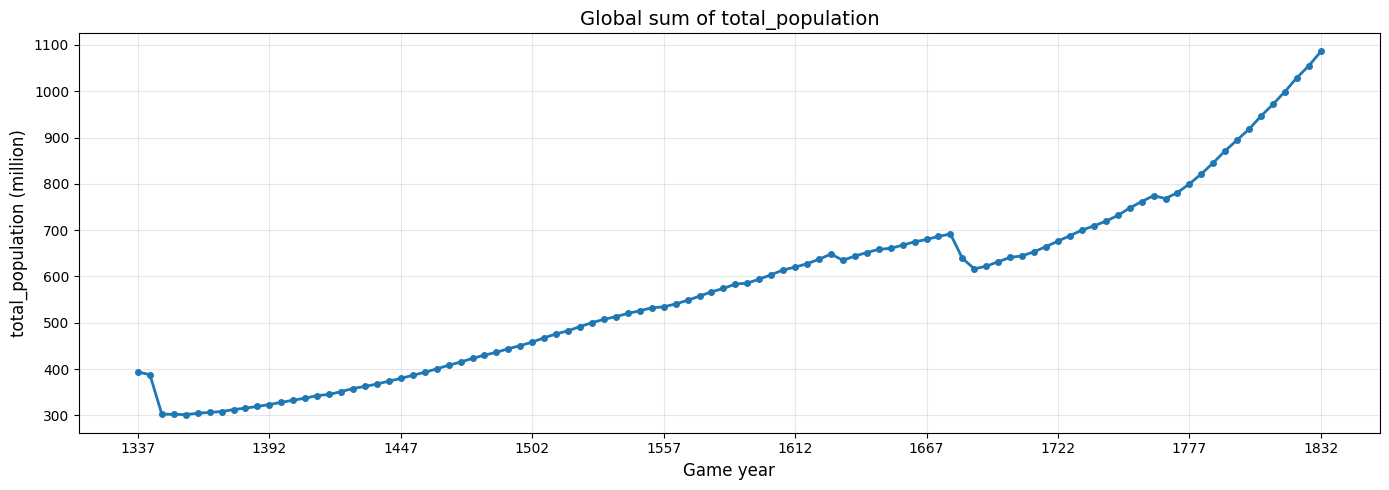

In [98]:
# Global sum of metric per snapshot (as graph)
# Use raw saves—comparison_df uses aggregation (mean/median/etc), so summing it would be wrong
labels = [c.replace(f"{metric}_", "") for c in comparison_df.columns if c.startswith(f"{metric}_")]
global_sum = pd.Series(
    {lb: saves[lb][metric].sum() for lb in labels if lb in saves and metric in saves[lb].columns}
).reindex(labels).dropna()
# Same units as main plot (millions for population only)
scale = 1e6 if metric in ("total_population", "population") else 1
y = (global_sum / scale).values
ylabel = f"{metric} (million)" if scale > 1 else metric

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(len(y)), y, linewidth=2, markersize=4, marker="o")
ax.set_title(f"Global sum of {metric}", fontsize=14)
ax.set_xlabel("Game year", fontsize=12)
ax.set_ylabel(ylabel, fontsize=12)
n_ticks = 10
n = len(y)
if n <= 1:
    tick_positions = list(range(n))
elif n <= n_ticks:
    tick_positions = list(range(n))
else:
    step = (n - 1) / (n_ticks - 1)
    tick_positions = [int(round(i * step)) for i in range(n_ticks)]
tick_labels = [start_year + pos * years_per_snapshot for pos in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.grid(True, axis="both", alpha=0.3)
plt.tight_layout()
plt.show()

In [99]:
"""Biggest changes (by absolute value) from first to last snapshot."""
metric_cols = [c for c in comparison_df.columns if c.startswith(f"{metric}_")]
if len(metric_cols) < 2:
    print("Need at least 2 snapshots to compute change.")
else:
    first_col, last_col = metric_cols[0], metric_cols[-1]
    change_df = comparison_df[[comparison] + [first_col, last_col]].copy()
    change_df["_change"] = change_df[last_col] - change_df[first_col]
    change_df = change_df.rename(columns={first_col: "start", last_col: "end"})
    mask = change_df["start"] != 0
    change_df["pct_change"] = float("inf")
    change_df.loc[mask, "pct_change"] = (
        (change_df.loc[mask, "end"] - change_df.loc[mask, "start"])
        / change_df.loc[mask, "start"]
        * 100
    )
    change_df = change_df[change_df["_change"] != 0]

    # Population: scale millions to thousands for display; other metrics (e.g. bldg_*) stay raw
    if metric in ("total_population", "population"):
        for col in ("start", "end", "_change"):
            change_df[col] = (change_df[col] / 1000).astype(int)
    else:
        for col in ("start", "end", "_change"):
            change_df[col] = change_df[col].round(0).astype(int)

    n_change = min(n, len(change_df))
    display(change_df.reindex(change_df["_change"].abs().sort_values(ascending=False).index).head(n_change))

,macro_region_pkl,start,end,_change,pct_change
2,western_europe,56410,335113,278702,4.940648e+02
3,eastern_europe,22770,125855,103085,4.527077e+02
0,east_asia,104936,180243,75306,7.176351e+01
5,south_east_asia,17859,72214,54355,3.043504e+02
4,middle_east,18843,68595,49752,2.640336e+02
10,west_africa,10666,57025,46358,4.346093e+02
8,east_africa,13433,36049,22616,1.683661e+02
1,south_asia,93224,111005,17781,1.907381e+01
9,north_africa,11047,24391,13344,1.207963e+02
12,central_asia,3903,13750,9847,2.522518e+02


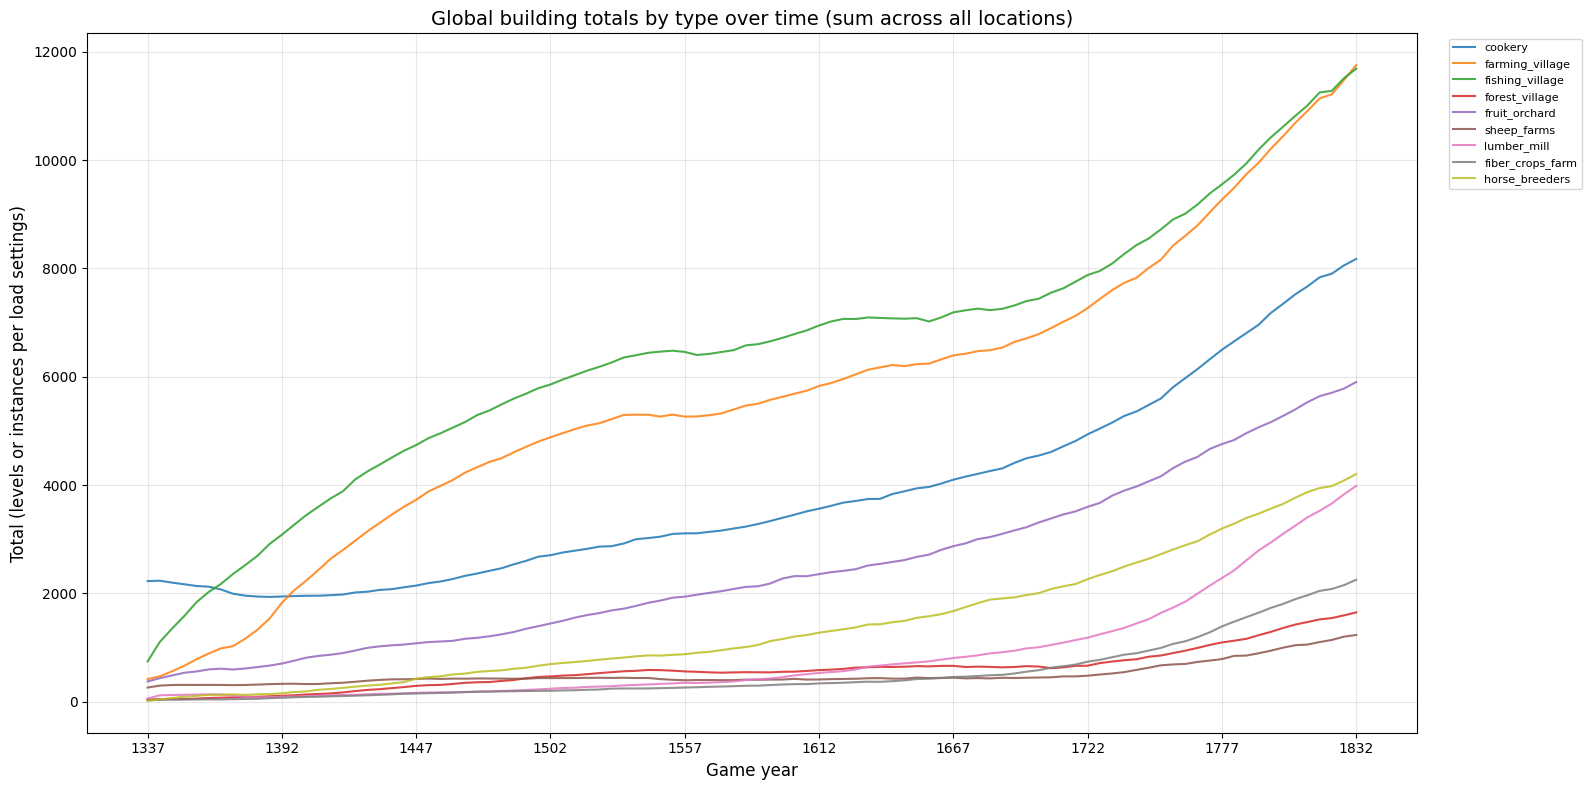

In [100]:
# Global building totals over time (world sum per building type; units match BUILDING_COUNT_MODE at load time)
MAX_BLDG_LINES = 40  # None = plot every bldg_* column; else top types by total across all snapshots

sample = next(iter(saves.values()))
bldg_cols = [c for c in sample.columns if c.startswith("bldg_")]
if not bldg_cols:
    print("No bldg_* columns — enable BUILDING_INCLUDE_ALL or BUILDING_SLUGS in the load cell.")
else:
    snap_order = sorted(saves.keys())
    data = {col: [float(saves[lb][col].sum()) for lb in snap_order] for col in bldg_cols}
    plot_df = pd.DataFrame(data, index=snap_order)

    if MAX_BLDG_LINES is not None and len(plot_df.columns) > MAX_BLDG_LINES:
        totals = plot_df.sum(axis=0).sort_values(ascending=False)
        keep = totals.head(MAX_BLDG_LINES).index.tolist()
        plot_df = plot_df[keep]

    legend_labels = [c.replace("bldg_", "", 1) for c in plot_df.columns]
    plot_df.columns = legend_labels
    plot_df.index = pd.RangeIndex(len(plot_df))

    n_ticks_b = 10
    n_snap = len(plot_df)
    if n_snap <= 1:
        tick_pos_b = list(range(n_snap))
    elif n_snap <= n_ticks_b:
        tick_pos_b = list(range(n_snap))
    else:
        step_b = (n_snap - 1) / (n_ticks_b - 1)
        tick_pos_b = [int(round(i * step_b)) for i in range(n_ticks_b)]
    tick_labels_b = [start_year + pos * years_per_snapshot for pos in tick_pos_b]

    fig, ax = plt.subplots(figsize=(16, 8))
    plot_df.plot(ax=ax, linewidth=1.5, markersize=3, alpha=0.85)
    ax.set_title("Global building totals by type over time (sum across all locations)", fontsize=14)
    ax.set_xlabel("Game year", fontsize=12)
    ax.set_ylabel("Total (levels or instances per load settings)", fontsize=12)
    ax.set_xticks(tick_pos_b)
    ax.set_xticklabels(tick_labels_b)
    ax.grid(True, axis="both", alpha=0.3)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, ncol=1)
    plt.tight_layout()
    plt.show()